<a href="https://colab.research.google.com/github/yacostac21-dev/Parcial-1Grupo-A/blob/main/Copia_de_Te_damos_la_bienvenida_a_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("data[1].csv", sep=";")

In [ ]:
df["Target"] = df["Target"].astype(str).str.strip()

df["Target"] = df["Target"].replace({
    "Dropout":0,
    "Enrolled":1,
    "Graduate":2
})

/tmp/ipython-input-1617/969409856.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Target"] = df["Target"].replace({


In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
X = pd.get_dummies(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.752542372881356

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

accuracy_score(y_test, rf_pred)

0.7581920903954802

In [ ]:
import pandas as pd

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(10)

,Variable,Importancia
30,Curricular units 2nd sem (approved),0.148805
31,Curricular units 2nd sem (grade),0.098220
24,Curricular units 1st sem (approved),0.091247
25,Curricular units 1st sem (grade),0.066143
16,Tuition fees up to date,0.043335
29,Curricular units 2nd sem (evaluations),0.043245
12,Admission grade,0.041423
6,Previous qualification (grade),0.037409
19,Age at enrollment,0.036206
23,Curricular units 1st sem (evaluations),0.036159


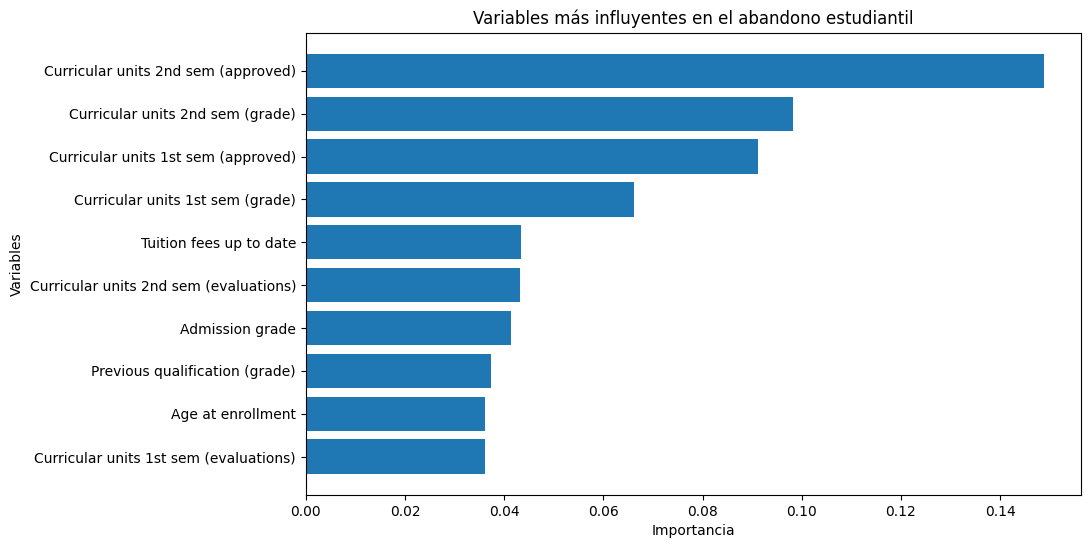

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["Variable"], top_features["Importancia"])

plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.title("Variables más influyentes en el abandono estudiantil")

plt.gca().invert_yaxis()

plt.show()

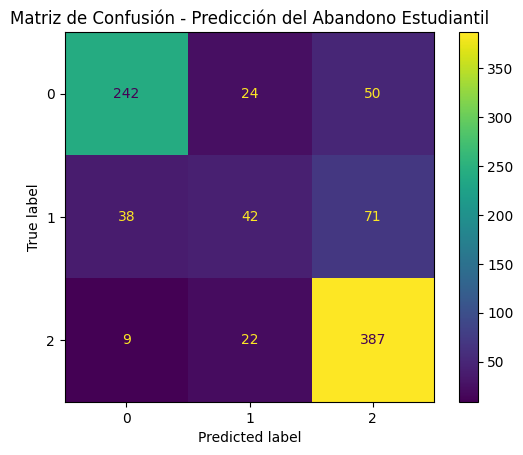

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Matriz de Confusión - Predicción del Abandono Estudiantil")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80       316
           1       0.48      0.28      0.35       151
           2       0.76      0.93      0.84       418

    accuracy                           0.76       885
   macro avg       0.69      0.66      0.66       885
weighted avg       0.74      0.76      0.74       885



In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

rf.fit(X_train_bal, y_train_bal)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

NameError: name 'rf' is not defined

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

rf.fit(X_train_bal, y_train_bal)

rf_pred = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.73      0.78       316
           1       0.44      0.47      0.45       151
           2       0.81      0.87      0.84       418

    accuracy                           0.75       885
   macro avg       0.70      0.69      0.69       885
weighted avg       0.76      0.75      0.75       885

